* Nota: A análise descritiva foi estruturada com foco na carteira de títulos liquidados, avaliando o comportamento de pagamento dos sacados, os prazos de liquidação efetiva frente ao vencimento e a concentração de volume por fundo, cedente e região.


In [1]:
# bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import matplotlib.patches as mpatches
import plotly.express as px
import itertools

In [2]:
# limpeza e conversão
df = pd.read_csv('BASE_TITULOS.txt', sep='\t')
df.columns = df.columns.str.strip() 

colunas_financeiras = ['VALOR_REAL', 'VALOR_DESAGIO', 'TAXA_MENSAL']
for col in colunas_financeiras:
    if df[col].dtype == 'O': 
        df[col] = df[col].str.replace(',', '.').astype(float)

In [3]:
# conversao de datas
df['VENCIMENTO'] = pd.to_datetime(df['VENCIMENTO'], format='%d/%m/%Y', errors='coerce')
df['DATA_EMISSAO'] = pd.to_datetime(df['DATA_EMISSAO'], format='%d/%m/%Y', errors='coerce')
df['DATA_PAGAMENTO'] = pd.to_datetime(df['DATA_PAGAMENTO'], format='%d/%m/%Y', errors='coerce')
df['MES_PAGAMENTO'] = df['DATA_PAGAMENTO'].dt.to_period('M').astype(str)

# Prazo de permanência na carteira

Fazendo a subtração da data de pagamento e data emissão (considerando data de emisssão a data da aquisição do título) temos uma idea de quanto tempo o título permaneceu na carteira até ser liquidado.

In [4]:
# prazo de permanencia e de liquidação
df['PRAZO_PERMANENCIA']=(df['DATA_PAGAMENTO'] - df['DATA_EMISSAO']).dt.days


In [5]:
# mapeamento de pagamento no prazo, no dia, até 7 dias e mais de 7 dias de atraso
df['DIFERENCA_DIAS'] = (df['VENCIMENTO'] - df['DATA_PAGAMENTO']).dt.days

condicoes = [
    df['DIFERENCA_DIAS'] > 0,
    df['DIFERENCA_DIAS'] == 0,
    (df['DIFERENCA_DIAS'] < 0) & (df['DIFERENCA_DIAS'] >= -7),
    df['DIFERENCA_DIAS'] < -7
]

status_ordem = [
    'Antes do vencimento',
    'No dia do vencimento',
    'Até 7 dias do vencimento',
    'Mais de 7 dias de atraso' 
]

df['STATUS_PAGAMENTO'] = np.select(condicoes, status_ordem, default='Sem data informada')

In [6]:
# volume por fundo, receita de deságio e taxa de pagamento
volume_por_fundo = df.groupby('NOME_FUNDO')['VALOR_REAL'].sum()
receita_desagio = df.groupby('NOME_FUNDO')['VALOR_DESAGIO'].sum().astype(float).round(2)
taxa_pagamento = df.groupby('NOME_FUNDO')['STATUS_LIQ_TITULO'].value_counts(normalize=True)

In [7]:
# concentração por cedente
concentracao_cedente = df.groupby(['NOME_FUNDO', 'CEDENTE'])['VALOR_REAL'].sum().reset_index()
concentracao_cedente = concentracao_cedente.sort_values(by=['NOME_FUNDO', 'VALOR_REAL'], ascending=[True, False])
top5_cedente_por_fundo = concentracao_cedente.groupby('NOME_FUNDO').head(5)

In [8]:
# concentração por sacado
concentracao_sacado = df.groupby(['NOME_FUNDO','SACADO'])['VALOR_REAL'].sum().reset_index()
concentracao_sacado = concentracao_sacado.sort_values(by=['NOME_FUNDO', 'VALOR_REAL'], ascending=[True, False])
top5_sacado_por_fundo = concentracao_sacado.groupby('NOME_FUNDO').head(5)

In [9]:
# concentração por estado do cedente
regionalizacao = df.groupby(['NOME_FUNDO','ESTADO_CEDENTE'])['VALOR_REAL'].sum().reset_index()
regionalizacao = regionalizacao.sort_values(by=['NOME_FUNDO', 'VALOR_REAL'], ascending=[True, False])
top5_estado_por_fundo = regionalizacao.groupby('NOME_FUNDO').head(5)

In [10]:
# concentração por estado do sacado
regionalizacao = df.groupby(['NOME_FUNDO','ESTADO_SACADO'])['VALOR_REAL'].sum().reset_index()
regionalizacao = regionalizacao.sort_values(by=['NOME_FUNDO', 'VALOR_REAL'], ascending=[True, False])
top5_estado_por_fundo = regionalizacao.groupby('NOME_FUNDO').head(5)

In [11]:
# taxa ponderada por valor real
df_calc = df.dropna(subset=['TAXA_MENSAL', 'VALOR_REAL', 'STATUS_LIQ_TITULO']).copy()

def calcular_media_ponderada(x):
    taxa = x['TAXA_MENSAL']
    peso = x['VALOR_REAL']
    return np.average(taxa, weights=peso)

taxa_ponderada_fundo = df_calc.groupby('NOME_FUNDO').apply(calcular_media_ponderada)

In [12]:
# indice de liquidez e indice de liquidez por mês
df_calc['VALOR_EM_DIA'] = np.where(df_calc['STATUS_LIQ_TITULO'] == 'EM_DIA', df_calc['VALOR_REAL'], 0)

liquidez_fundo = df_calc.groupby('NOME_FUNDO')[['VALOR_REAL', 'VALOR_EM_DIA']].sum().reset_index()
liquidez_fundo['Indice_Liquidez_(%)'] = (liquidez_fundo['VALOR_EM_DIA'] / liquidez_fundo['VALOR_REAL']) 

liq_mes = df_calc.groupby(['NOME_FUNDO','MES_PAGAMENTO'])[['VALOR_REAL', 'VALOR_EM_DIA']].sum().reset_index()
liq_mes['INDICE_LIQUIDEZ_(%)'] = (liq_mes['VALOR_EM_DIA'] / liq_mes['VALOR_REAL'])

In [13]:
# volume por produto
vol_prod = df_calc.groupby(['NOME_FUNDO', 'TIPO_PRODUTO'])['VALOR_REAL'].sum().unstack(fill_value=0)
vol_prod = vol_prod.add_prefix('VOL_')

# Tabela informações consolidadas

Informações da carteira de cada fundo

In [14]:
# tabela com receita, volume total de pagamento e total por produto, taxa ponderada, liquidez e status de pagamento e de atraso
col_volume = volume_por_fundo.rename('VOLUME_TOTAL')
col_receita = receita_desagio.rename('RECEITA_DESAGIO')
col_taxa_pond = taxa_ponderada_fundo.rename('TAXA_MEDIA_PONDERADA')
col_liquidez = liquidez_fundo.set_index('NOME_FUNDO')[['Indice_Liquidez_(%)']]
col_taxa_pag = taxa_pagamento.unstack(fill_value=0).add_prefix('%_STATUS_')

tabela = pd.concat([
    col_volume, 
    col_receita, 
    col_taxa_pond, 
    col_liquidez, 
    col_taxa_pag, 
    vol_prod 
], axis=1)

tabela_final = tabela.round(4).reset_index()

tabela_final

,NOME_FUNDO,VOLUME_TOTAL,RECEITA_DESAGIO,TAXA_MEDIA_PONDERADA,Indice_Liquidez_(%),%_STATUS_ATRASO,%_STATUS_EM_DIA,VOL_Produto 1,VOL_Produto 2,VOL_Produto 3,VOL_Produto 4,VOL_Produto 5
0,Fundo 1,25976410.72,1928355.17,0.0496,0.8388,0.1567,0.8433,18657612.82,7318797.90,0.00,0.00,0.00
1,Fundo 2,31727329.88,2382740.27,0.0567,0.8818,0.1183,0.8817,12746363.29,5743039.55,12566127.91,0.00,668771.35
2,Fundo 3,329850.49,21639.13,0.0350,0.4126,0.7255,0.2745,182662.04,0.00,0.00,0.00,147188.45
3,Fundo 4,1981531.61,220915.49,0.0751,0.2858,0.8326,0.1674,551366.36,1042804.48,72812.40,0.00,306218.19
4,Fundo 5,561044.43,19308.34,0.0056,1.0000,0.0000,1.0000,0.00,0.00,0.00,561044.43,0.00


In [15]:
# analise do limite de cedente
analise_limite = df.groupby(['NOME_FUNDO','CEDENTE']).agg(VOLUME=('VALOR_REAL', 'sum'),LIMITE=('LIMITE_CEDENTE', 'max'))
analise_limite['TAXA_UTILIZACAO_(%)'] = (analise_limite['VOLUME'] / analise_limite['LIMITE']) 
analise_limite_sorted = analise_limite[analise_limite['TAXA_UTILIZACAO_(%)'] > 0].sort_values(by='TAXA_UTILIZACAO_(%)', ascending=False).round(2)

# Gráfico de indice de liquidez

Notamos que após 2018 não houve pagamentos antes ou no dia do vencimento, ou seja, se houve pagamento nesses meses foi em atraso.

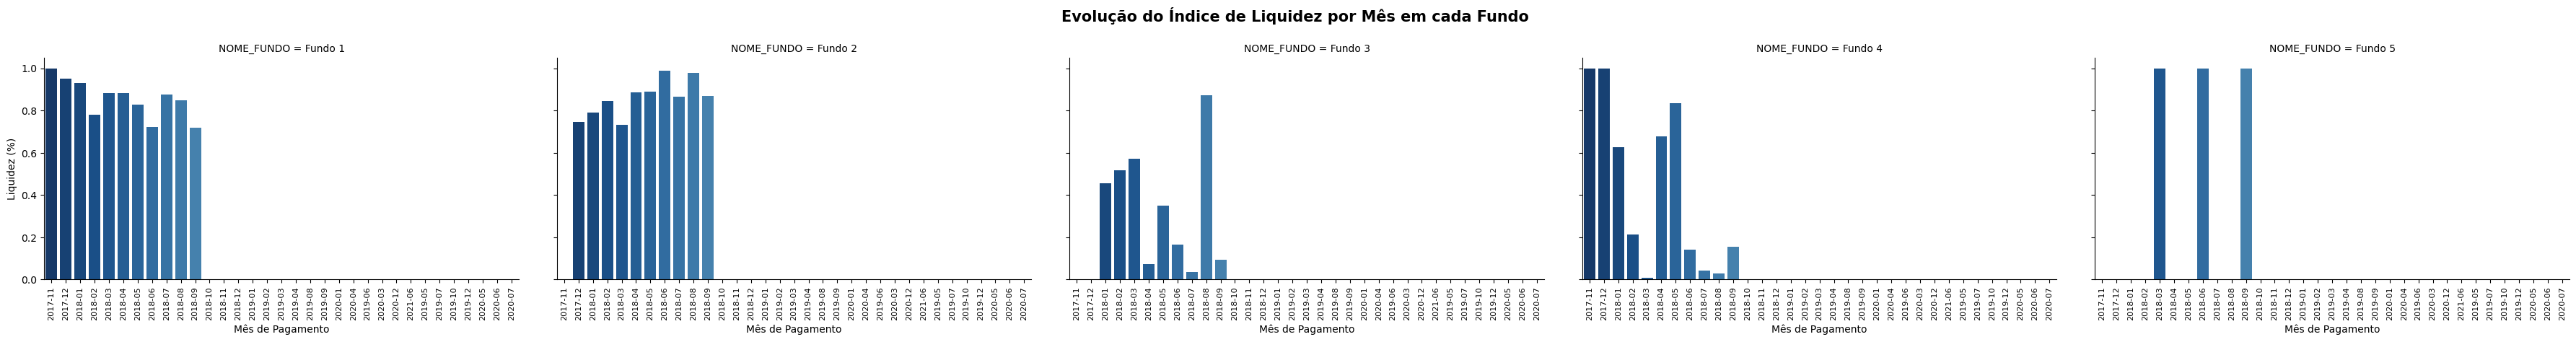

In [30]:
# grafico de liquidez por mes_ano

grafico_liquidez = sns.catplot(
    data=liq_mes, 
    x='MES_PAGAMENTO', 
    y='INDICE_LIQUIDEZ_(%)', 
    col='NOME_FUNDO', 
    col_wrap=5, 
    kind='bar', 
    height=4, 
    aspect=1.8,       
    palette='Blues_r'
)

grafico_liquidez.figure.suptitle('Evolução do Índice de Liquidez por Mês em cada Fundo', fontsize=15, fontweight='bold', y=1.09)

for ax in grafico_liquidez.axes.flat:
    ax.tick_params(axis='x', rotation=90, labelsize=8) 
    ax.set_ylabel('Liquidez (%)')
    ax.set_xlabel('Mês de Pagamento')

plt.show()

# Gráfico de liquidações

Esse gráfico mostra o valor financeiro de pagamentos em atraso, em até 7 dias de vencimento, antes do vencimento e no dia do vencimento.
Podemos notar junto com o gráfico anterior de indice de liquidez que os pagamentos ficaram em atraso após 2018.

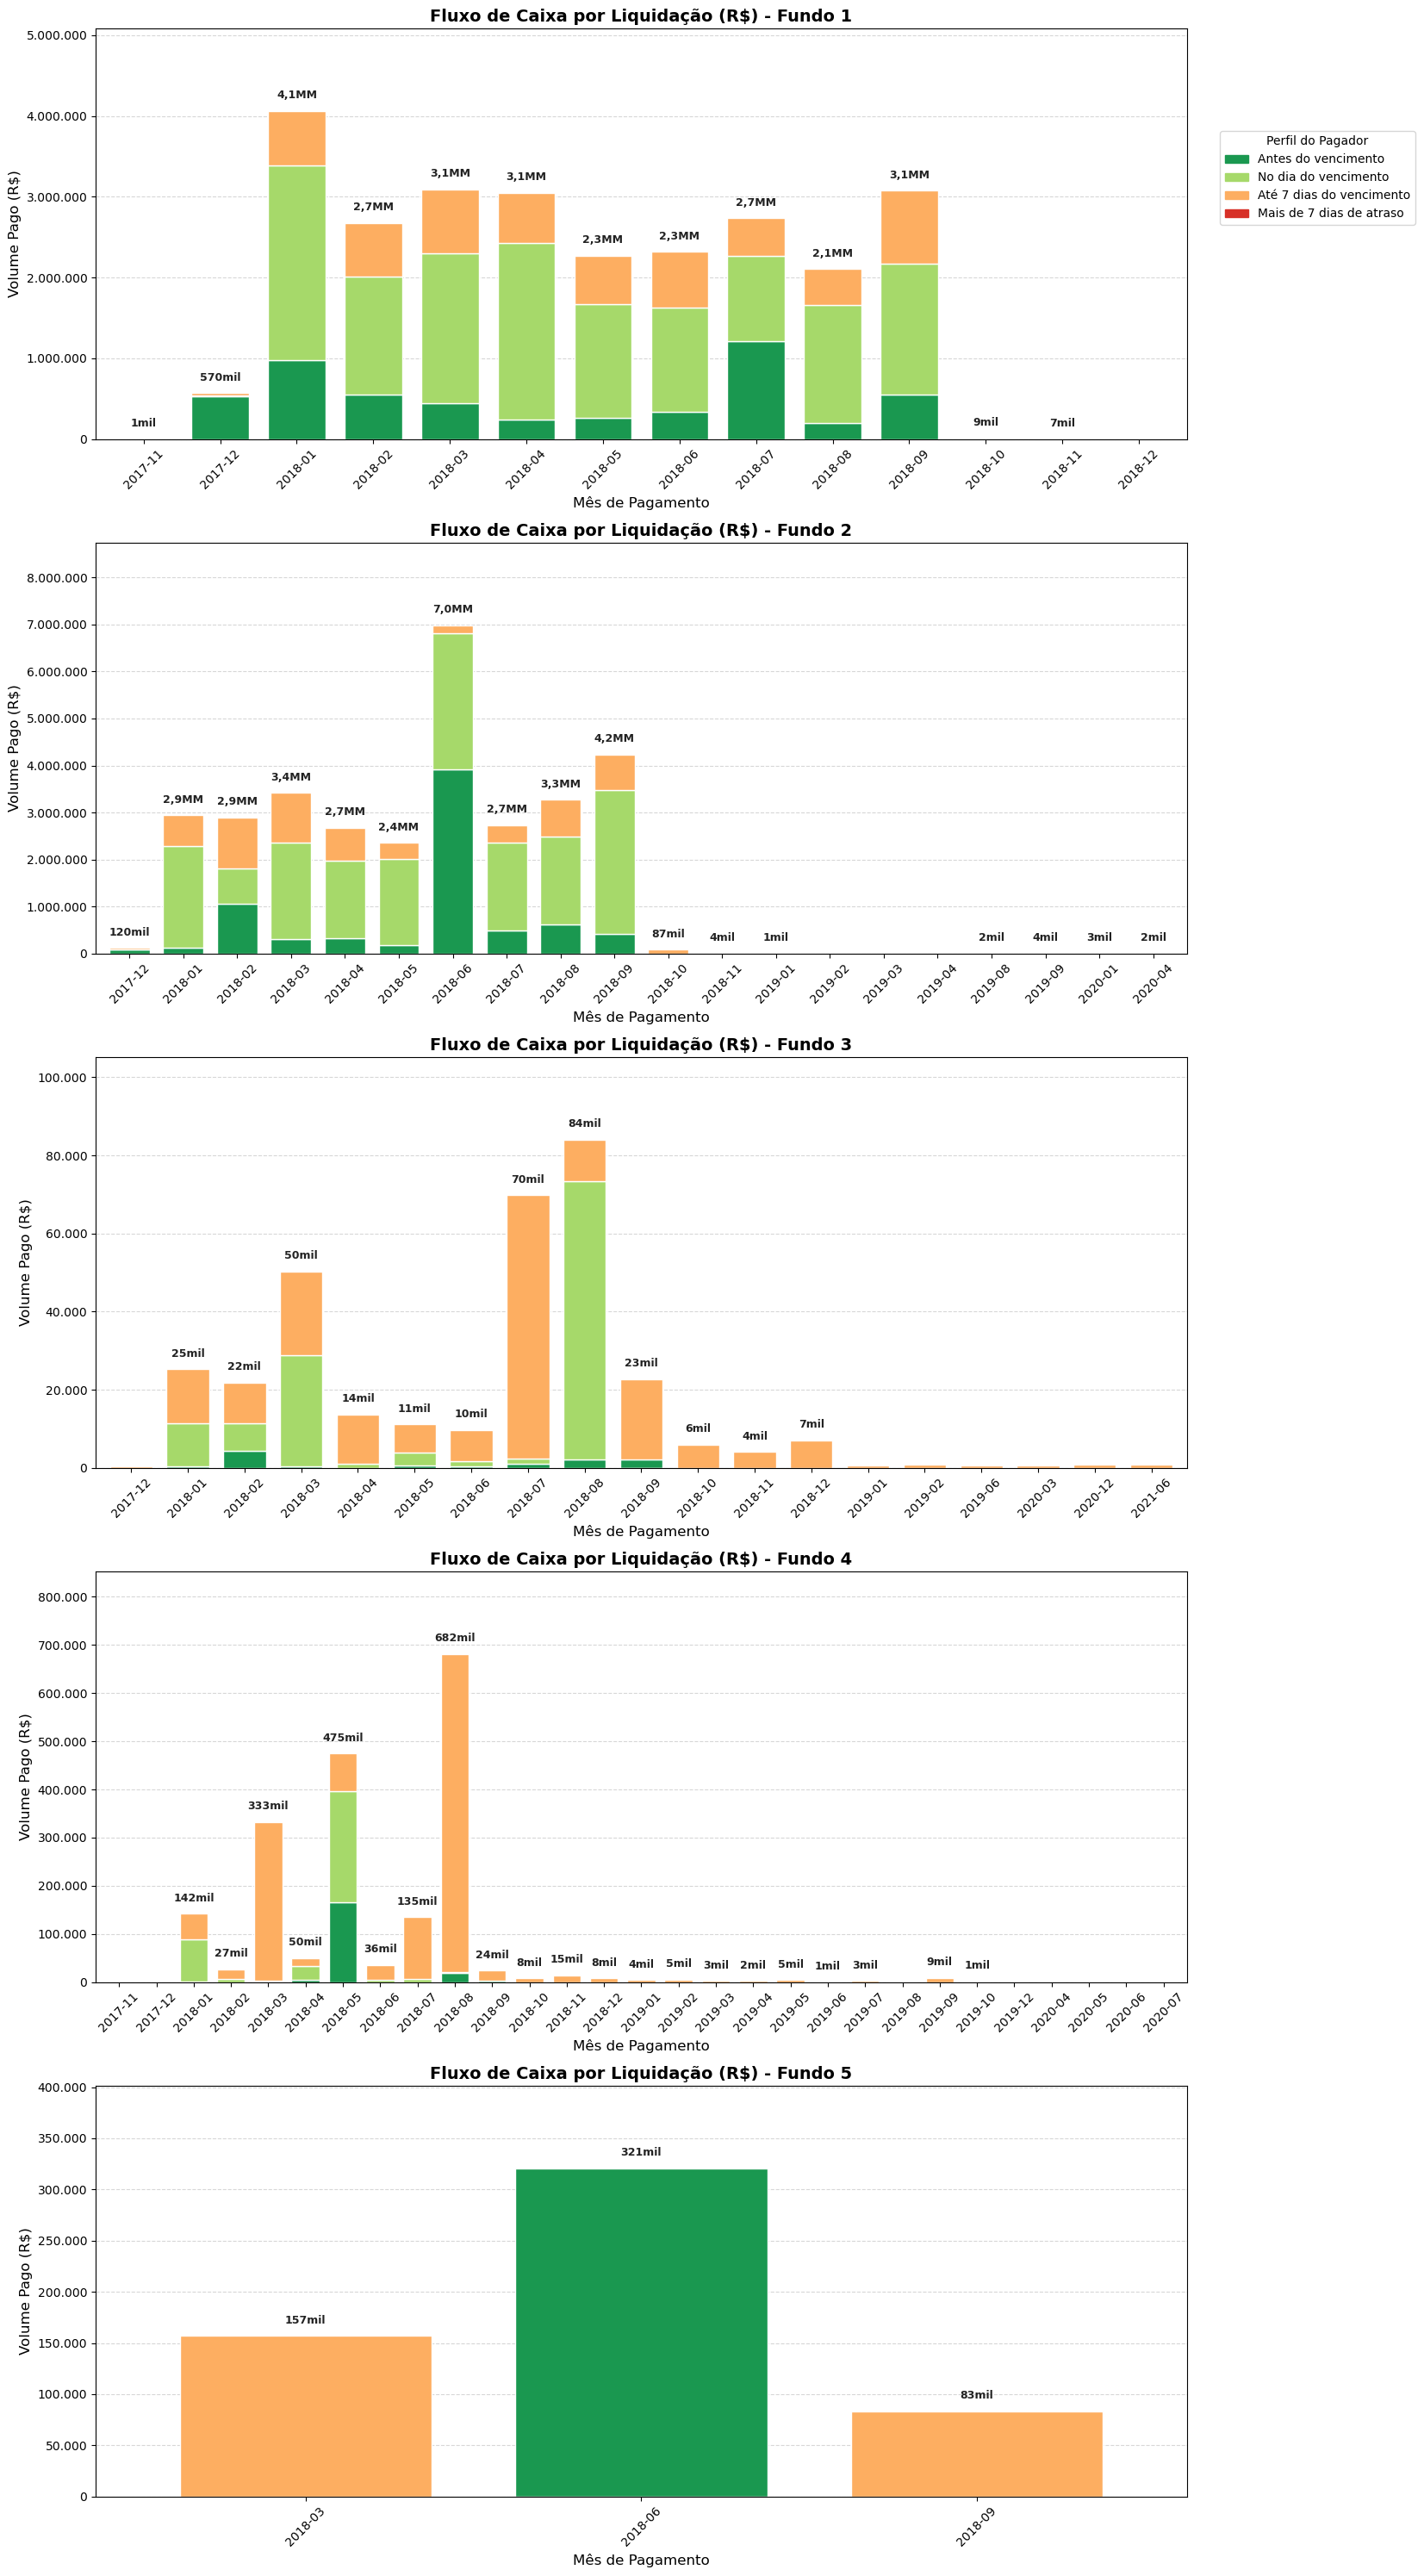

In [17]:
# Gráfico de pagamento por status
cores_status = {
    'Antes do vencimento': '#1a9850',      
    'No dia do vencimento': '#a6d96a',     
    'Até 7 dias do vencimento': '#fdae61',     
    'Mais de 7 dias de atraso': '#d73027'  
}

fundos = sorted(df_calc['NOME_FUNDO'].unique())
fig, axes = plt.subplots(nrows=len(fundos), ncols=1, figsize=(14, 6 * len(fundos)))

if len(fundos) == 1:
    axes = [axes]

def formatar_cifra(valor):
    if valor >= 1e6:
        return f'{valor/1e6:.1f}MM'.replace('.', ',')
    elif valor >= 1e3:
        return f'{valor/1e3:.0f}mil'
    else:
        return f'{valor:.0f}'

for ax, fundo in zip(axes, fundos):
    dados_fundo = df_calc[df_calc['NOME_FUNDO'] == fundo]
    
    pivot = dados_fundo.groupby(['MES_PAGAMENTO', 'STATUS_PAGAMENTO'])['VALOR_REAL'].sum().unstack(fill_value=0)
    
    colunas_presentes = [col for col in status_ordem if col in pivot.columns]
    pivot = pivot[colunas_presentes]
    cores_plot = [cores_status[col] for col in colunas_presentes]
    
    pivot.plot(
        kind='bar', 
        stacked=True, 
        ax=ax, 
        color=cores_plot, 
        edgecolor='white',
        width=0.75,
        legend=False 
    )
    
    totais = pivot.sum(axis=1) 
    for i, total in enumerate(totais):
        if total > 999:
            texto = formatar_cifra(total)
            ax.text(i, total + (totais.max() * 0.03), texto, ha='center', va='bottom', fontsize=9, fontweight='bold', color='#222')

    ax.set_title(f'Fluxo de Caixa por Liquidação (R$) - {fundo}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Volume Pago (R$)', fontsize=12)
    ax.set_xlabel('Mês de Pagamento', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'.replace(',', '.')))
    ax.set_ylim(0, totais.max() * 1.25)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

legend_patches = [mpatches.Patch(color=cor, label=status) for status, cor in cores_status.items()]
fig.legend(handles=legend_patches, title='Perfil do Pagador', bbox_to_anchor=(1.01, 0.95), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

# Gráficos geográficos de concentração de sacado nos estados

Notamos por esses gráficos que a maior concentração dos sacados é na região sudoeste do país. Isso pode significar maior risco financeiro ao fundo. O fundo 3 tem maior diversidade de concentração comparado aos outros fundos.

In [18]:
# grafico da concentração por estados do sacado

estados_brasil = [
    'AC', 'AL', 'AP', 'AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 
    'MT', 'MS', 'MG', 'PA', 'PB', 'PR', 'PE', 'PI', 'RJ', 'RN', 
    'RS', 'RO', 'RR', 'SC', 'SP', 'SE', 'TO'
]

df_limpo = df[df['ESTADO_SACADO'].isin(estados_brasil)].copy()
fundos = sorted(df_limpo['NOME_FUNDO'].dropna().unique())

grid_completo = []
for fundo in fundos:
    for uf in estados_brasil:
        grid_completo.append({'NOME_FUNDO': fundo, 'ESTADO_SACADO': uf})

df_grid = pd.DataFrame(grid_completo)

df_real = df_limpo.groupby(['NOME_FUNDO', 'ESTADO_SACADO'])['VALOR_REAL'].sum().reset_index()

df_mapa_completo = pd.merge(df_grid, df_real, on=['NOME_FUNDO', 'ESTADO_SACADO'], how='left')

df_mapa_completo['STATUS_OPERACAO'] = df_mapa_completo['VALOR_REAL'].apply(
    lambda x: 'Sem Operação / R$ 0' if pd.isna(x) or x == 0 else 'Com Operação'
)

geojson_url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"

for fundo in fundos:
    df_fundo = df_mapa_completo[df_mapa_completo['NOME_FUNDO'] == fundo].copy()
    
    df_fundo['VALOR_FORMATADO'] = df_fundo['VALOR_REAL'].apply(lambda x: f"R$ {x:,.2f}".replace(',', '_').replace('.', ',').replace('_', '.') if pd.notna(x) else "R$ 0,00")

    fig = px.choropleth(
        df_fundo,
        geojson=geojson_url,
        locations='ESTADO_SACADO',
        featureidkey="properties.sigla",
        color='VALOR_REAL',
        color_continuous_scale="oranges",
        range_color=[1, df_fundo['VALOR_REAL'].max() if df_fundo['VALOR_REAL'].max() > 0 else 1],
        labels={'VALOR_REAL': 'Volume Real (R$)', 'ESTADO_SACADO': 'Estado'},
        hover_name='ESTADO_SACADO',
        hover_data={'VALOR_REAL': False, 'VALOR_FORMATADO': True, 'ESTADO_SACADO': False}
    )
    
    fig.update_traces(
        selector=dict(type='choropleth'),
        zmin=1 
    )
    
    fig.update_geos(
        center={"lat": -14.2350, "lon": -51.9253}, 
        scope="south america", 
        visible=True
    )

    fig.update_layout(
        title_text=f'<b>Concentração Geográfica - {fundo}</b>',
        title_x=0.5,
        title_font_size=16,
        width=700,
        height=500,
        margin={"r":20, "t":60, "l":20, "b":20},
        paper_bgcolor='white'
    )
    
    fig.show()

# Gráfico de adimplência por estado do sacado

Complementa o anterior e conseguimos ver os estados com melhores pagadores, não sendo necessariamente o com maior concentração, por isso o risco acaba aumentando com menor diversificação de concentração.

In [19]:
# grafico de adimplencia por estado do sacado

estados_brasil = [
    'AC', 'AL', 'AP', 'AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 
    'MT', 'MS', 'MG', 'PA', 'PB', 'PR', 'PE', 'PI', 'RJ', 'RN', 
    'RS', 'RO', 'RR', 'SC', 'SP', 'SE', 'TO'
]

df_mapa_pontualidade = df_calc[df_calc['ESTADO_SACADO'].isin(estados_brasil)].copy()
df_mapa_pontualidade['PAGO_EM_DIA'] = np.where(df_mapa_pontualidade['STATUS_LIQ_TITULO'] == 'EM_DIA', df_mapa_pontualidade['VALOR_REAL'], 0)

regiao_pontualidade = df_mapa_pontualidade.groupby(['NOME_FUNDO', 'ESTADO_SACADO']).agg(
    VOLUME_TOTAL=('VALOR_REAL', 'sum'),
    VOLUME_EM_DIA=('PAGO_EM_DIA', 'sum')
).reset_index()

regiao_pontualidade['TAXA_EM_DIA_(%)'] = (regiao_pontualidade['VOLUME_EM_DIA'] / regiao_pontualidade['VOLUME_TOTAL']) * 100

all_funds = sorted(df_calc['NOME_FUNDO'].dropna().unique())
full_grid = pd.DataFrame(list(itertools.product(all_funds, estados_brasil)), columns=['NOME_FUNDO', 'ESTADO_SACADO'])

df_mapa_completo = pd.merge(full_grid, regiao_pontualidade, on=['NOME_FUNDO', 'ESTADO_SACADO'], how='left').fillna(0)

df_mapa_completo['TAXA_PLOT'] = df_mapa_completo['TAXA_EM_DIA_(%)'].replace(0, np.nan)

def formata_real(val):
    return f"R$ {val:,.2f}".replace(',', '_').replace('.', ',').replace('_', '.')

df_mapa_completo['VOL_TOTAL_FMT'] = df_mapa_completo['VOLUME_TOTAL'].apply(formata_real)
df_mapa_completo['VOL_EM_DIA_FMT'] = df_mapa_completo['VOLUME_EM_DIA'].apply(formata_real)
df_mapa_completo['TAXA_FMT'] = df_mapa_completo['TAXA_EM_DIA_(%)'].round(2).astype(str) + '%'

geojson_url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"

for fundo in all_funds:
    df_fundo = df_mapa_completo[df_mapa_completo['NOME_FUNDO'] == fundo].copy()
    
    fig = px.choropleth(
        df_fundo,
        geojson=geojson_url,
        locations='ESTADO_SACADO',
        featureidkey="properties.sigla",
        color='TAXA_PLOT',
        color_continuous_scale="Greens",
        range_color=[0, 100], 
        labels={'TAXA_PLOT': 'Taxa em Dia (%)', 'ESTADO_SACADO': 'Estado'},
        hover_name='ESTADO_SACADO',
        hover_data={
            'TAXA_PLOT': False, 
            'TAXA_FMT': True,
            'VOL_TOTAL_FMT': True,
            'VOL_EM_DIA_FMT': True,
            'ESTADO_SACADO': False
        }
    )
    
    fig.update_geos(
        center={"lat": -14.2350, "lon": -51.9253}, 
        scope="south america", 
        visible=True
    )
    
    fig.update_layout(
        title_text=f'<b>Taxa de Adimplência Geográfica - {fundo}</b>',
        title_x=0.5,
        title_font_size=16,
        width=700,
        height=500,
        margin={"r":20, "t":60, "l":20, "b":20}
    )
    
    fig.show()

# Gráfico de limite de cedente

Podemos ver que o cedente 11 dentro do fundo 2 fez operações que somadas ficaram acima do valor do limite (que nesse caso é de R$ 892857,00 e operaram R$3440000,00) e vemos o mesmo com o cedente 1 no fundo 2.

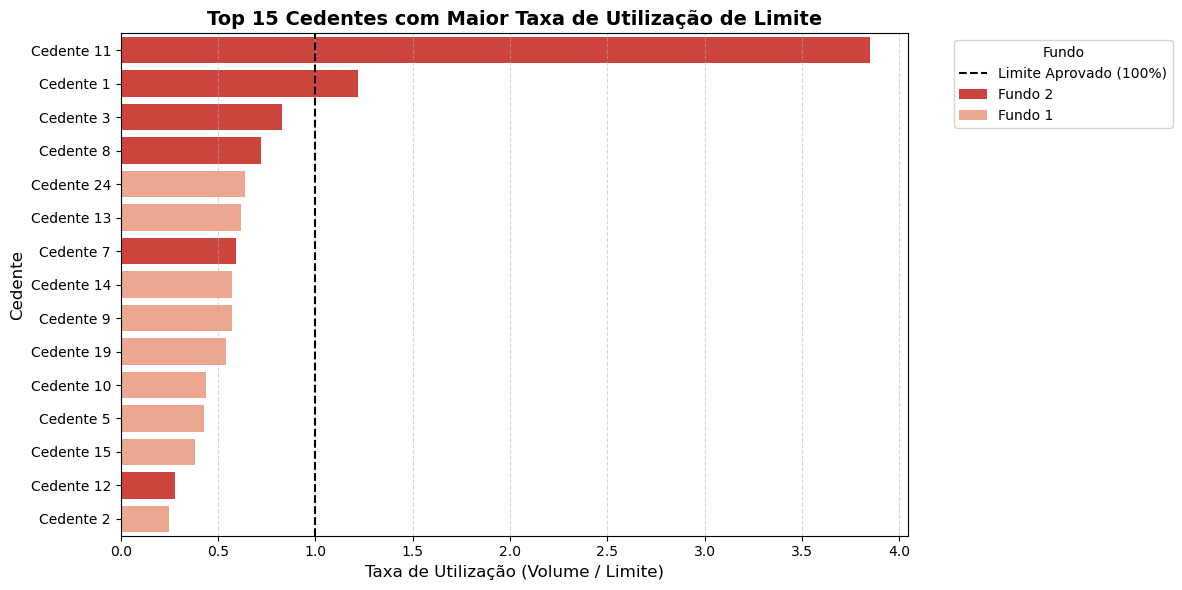

In [20]:
# grafico de limite de cedente
top_risco_limite = analise_limite_sorted.reset_index().head(15)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=top_risco_limite, 
    x='TAXA_UTILIZACAO_(%)', 
    y='CEDENTE', 
    hue='NOME_FUNDO', 
    palette='Reds_r',
    dodge=False
)

plt.title('Top 15 Cedentes com Maior Taxa de Utilização de Limite', fontsize=14, fontweight='bold')
plt.xlabel('Taxa de Utilização (Volume / Limite)', fontsize=12)
plt.ylabel('Cedente', fontsize=12)

plt.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5, label='Limite Aprovado (100%)')

plt.legend(title='Fundo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Gráfico de Permanência x Pagamento

Podemos observar por esse gráfico que os fundos de maior escala (como fundo 1 e 2) operam com prazos menores e maior antecipação de liquidação. Enquanto fundos de maior prazo de permanência fazem o pagamento na data de vencimento, próximo a data ou logo após o vencimento. 


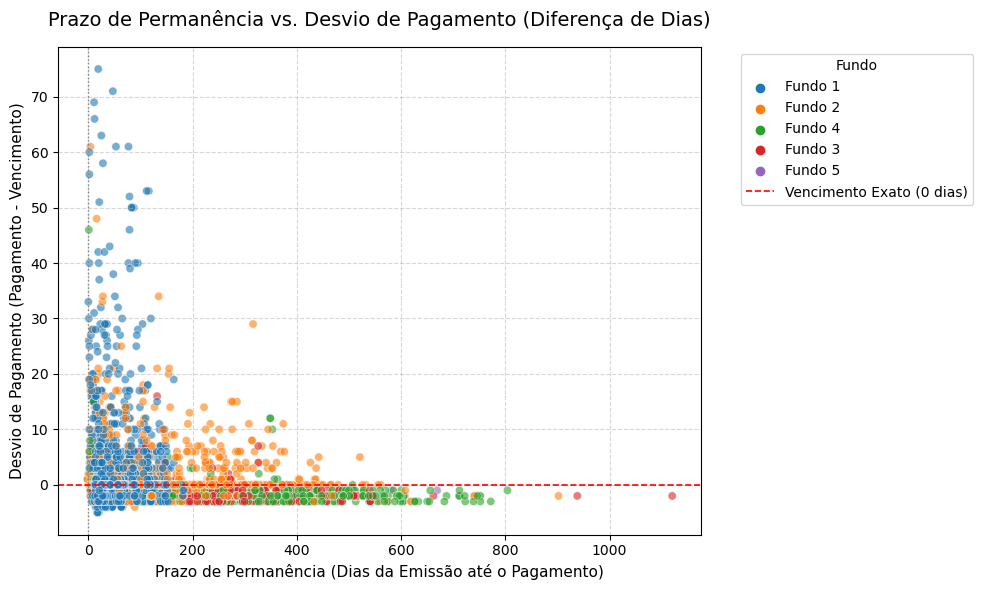

In [21]:
# Gráfico Prazo de Permanência x Diferença de Dias 

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='PRAZO_PERMANENCIA', 
    y='DIFERENCA_DIAS', 
    hue='NOME_FUNDO', 
    alpha=0.6, 
    palette='tab10',
    edgecolor='w'
)

plt.axhline(0, color='red', linestyle='--', linewidth=1.2, label='Vencimento Exato (0 dias)')

plt.title('Prazo de Permanência vs. Desvio de Pagamento (Diferença de Dias)', fontsize=14, pad=15)
plt.xlabel('Prazo de Permanência (Dias da Emissão até o Pagamento)', fontsize=11)
plt.ylabel('Desvio de Pagamento (Pagamento - Vencimento)', fontsize=11)
plt.axvline(0, color='gray', linestyle=':', linewidth=1)

plt.legend(title='Fundo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()